In [1]:
from tensorflow.keras.applications.vgg16 import VGG16

In [2]:
model = VGG16()

In [3]:
model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [5]:
from keras.utils import plot_model

#plot_model(model)

In [6]:
model.layers

In [7]:
for i in range(len(model.layers)):
	# check for convolutional layer
	if 'conv' not in model.layers[i].name:
		continue
	# get filter weights
	filters, biases = model.layers[i].get_weights()
	print("layer number",i,model.layers[i].name, filters.shape)

layer number 1 block1_conv1 (3, 3, 3, 64)
layer number 2 block1_conv2 (3, 3, 64, 64)
layer number 4 block2_conv1 (3, 3, 64, 128)
layer number 5 block2_conv2 (3, 3, 128, 128)
layer number 7 block3_conv1 (3, 3, 128, 256)
layer number 8 block3_conv2 (3, 3, 256, 256)
layer number 9 block3_conv3 (3, 3, 256, 256)
layer number 11 block4_conv1 (3, 3, 256, 512)
layer number 12 block4_conv2 (3, 3, 512, 512)
layer number 13 block4_conv3 (3, 3, 512, 512)
layer number 15 block5_conv1 (3, 3, 512, 512)
layer number 16 block5_conv2 (3, 3, 512, 512)
layer number 17 block5_conv3 (3, 3, 512, 512)


In [8]:
# retrieve weights from the second hidden layer
filters , bias = model.layers[1].get_weights()

In [9]:
filters.shape

(3, 3, 3, 64)

In [10]:

bias.shape

(64,)

In [11]:
# normalize filter values to 0-1 so we can visualize them
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

In [12]:
from matplotlib import pyplot as pyplot

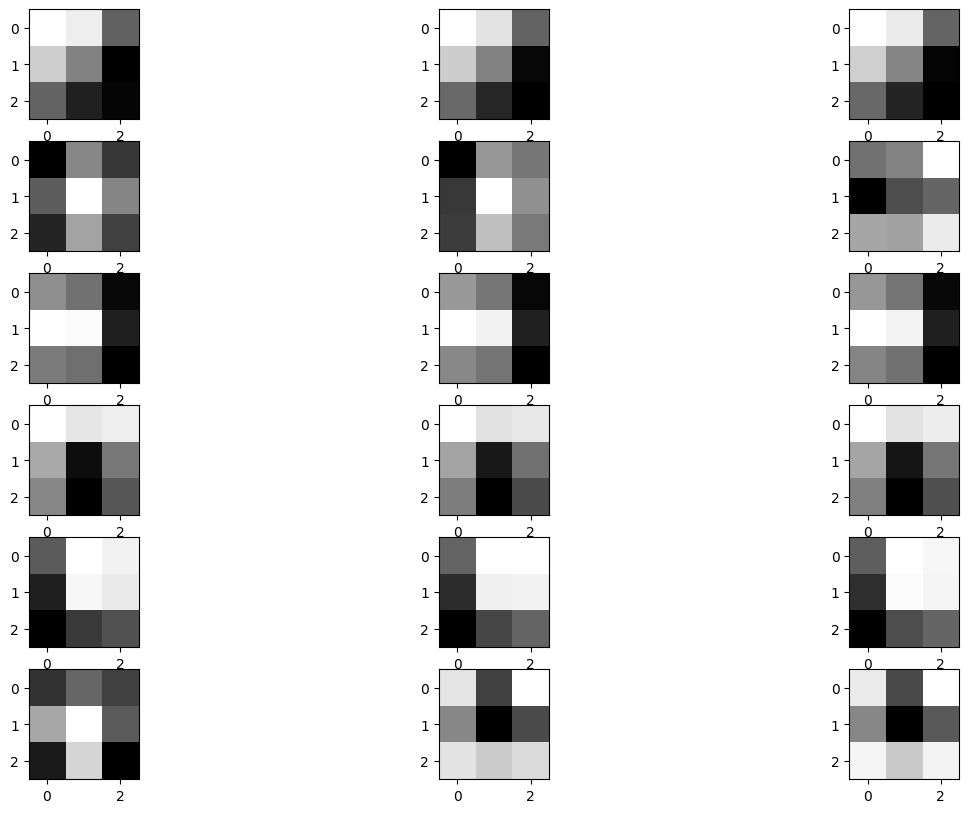

In [13]:
n_filters =6
ix=1
fig = pyplot.figure(figsize=(15,10))
for i in range(n_filters):
    # get the filters
    f = filters[:,:,:,i]
    for j in range(3):
        # subplot for 6 filters and 3 channels
        pyplot.subplot(n_filters,3,ix)
        pyplot.imshow(f[:,:,j] ,cmap='gray')
        ix+=1
#plot the filters
pyplot.show()

In [14]:
from tensorflow.keras import Model

In [15]:
model = Model(inputs=model.inputs , outputs=model.layers[1].output)

In [16]:
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import img_to_array
import numpy as np
from keras.applications.vgg16 import preprocess_input

In [20]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Correct local path - pick a tomato image
image = load_img("archive_extracted/train/tomatoes/img_p3_44.jpeg", target_size=(224, 224))

# Convert the image to an array
image = img_to_array(image)
print("Image loaded successfully with shape:", image.shape)


Image loaded successfully with shape: (224, 224, 3)


In [22]:
image = img_to_array(image)
# expand dimensions so that it represents a single 'sample'
image = np.expand_dims(image, axis=0)

image = preprocess_input(image)

In [23]:
image

array([[[[ 108.061    ,  110.221    ,  112.32     ],
         [ 108.061    ,  110.221    ,  112.32     ],
         [ 108.061    ,  110.221    ,  112.32     ],
         ...,
         [ -65.939    ,   92.221    ,  117.32     ],
         [ -56.939003 ,   90.221    ,  117.32     ],
         [ -46.939003 ,   88.221    ,  117.32     ]],

        [[ 108.061    ,  110.221    ,  112.32     ],
         [ 108.061    ,  110.221    ,  112.32     ],
         [ 108.061    ,  110.221    ,  112.32     ],
         ...,
         [ -86.939    ,   88.221    ,  110.32     ],
         [ -79.939    ,   86.221    ,  110.32     ],
         [ -70.939    ,   85.221    ,  110.32     ]],

        [[ 106.061    ,  108.221    ,  110.32     ],
         [ 106.061    ,  108.221    ,  110.32     ],
         [ 106.061    ,  108.221    ,  110.32     ],
         ...,
         [-103.939    ,   78.221    ,   99.32     ],
         [-103.939    ,   78.221    ,   99.32     ],
         [-103.939    ,   77.221    ,   99.32     ]],

1/1 [==============================] - 0s 329ms/step


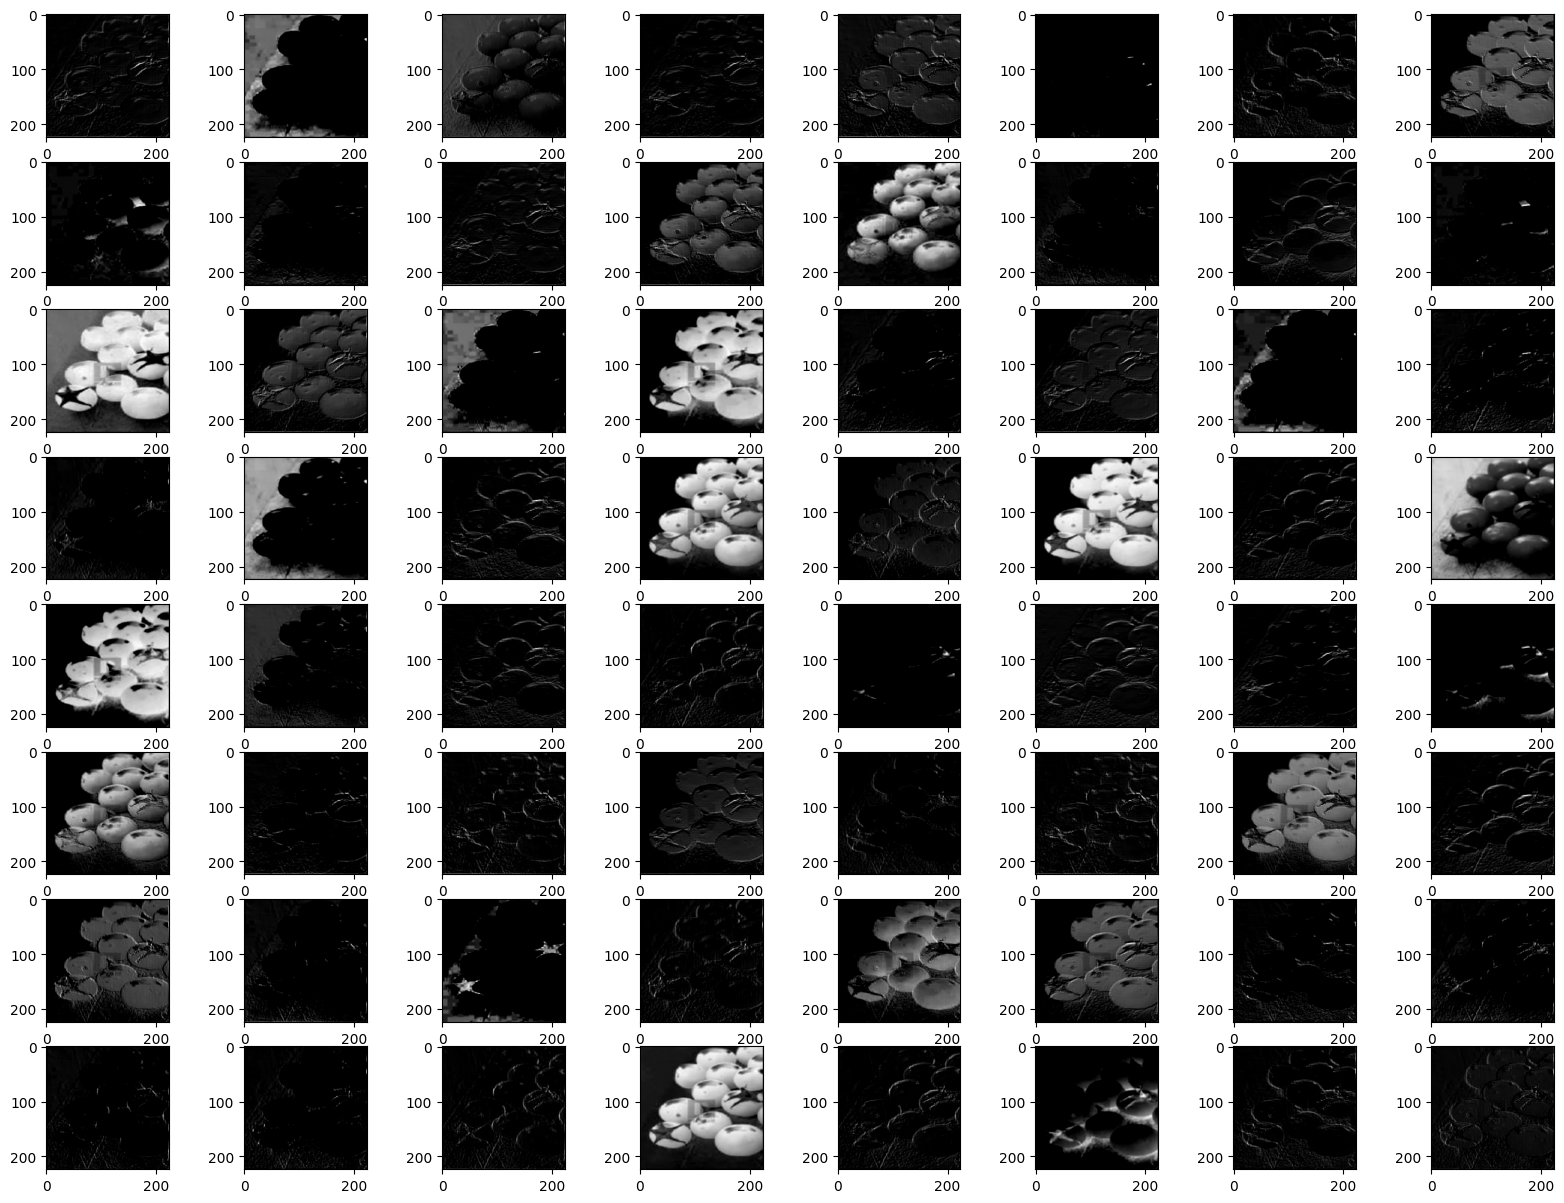

In [24]:
#calculating features_map
features = model.predict(image)

fig = pyplot.figure(figsize=(20,15))
for i in range(1,features.shape[3]+1):

    pyplot.subplot(8,8,i)
    pyplot.imshow(features[0,:,:,i-1] , cmap='gray')

In [25]:
model2 = VGG16()

In [26]:
layer_index = [ 2, 5 , 9 , 13 , 17]
outputs = [model2.layers[i].output for i in layer_index]

model3 = Model( inputs= model2.inputs, outputs = outputs)

1/1 [==============================] - 0s 418ms/step


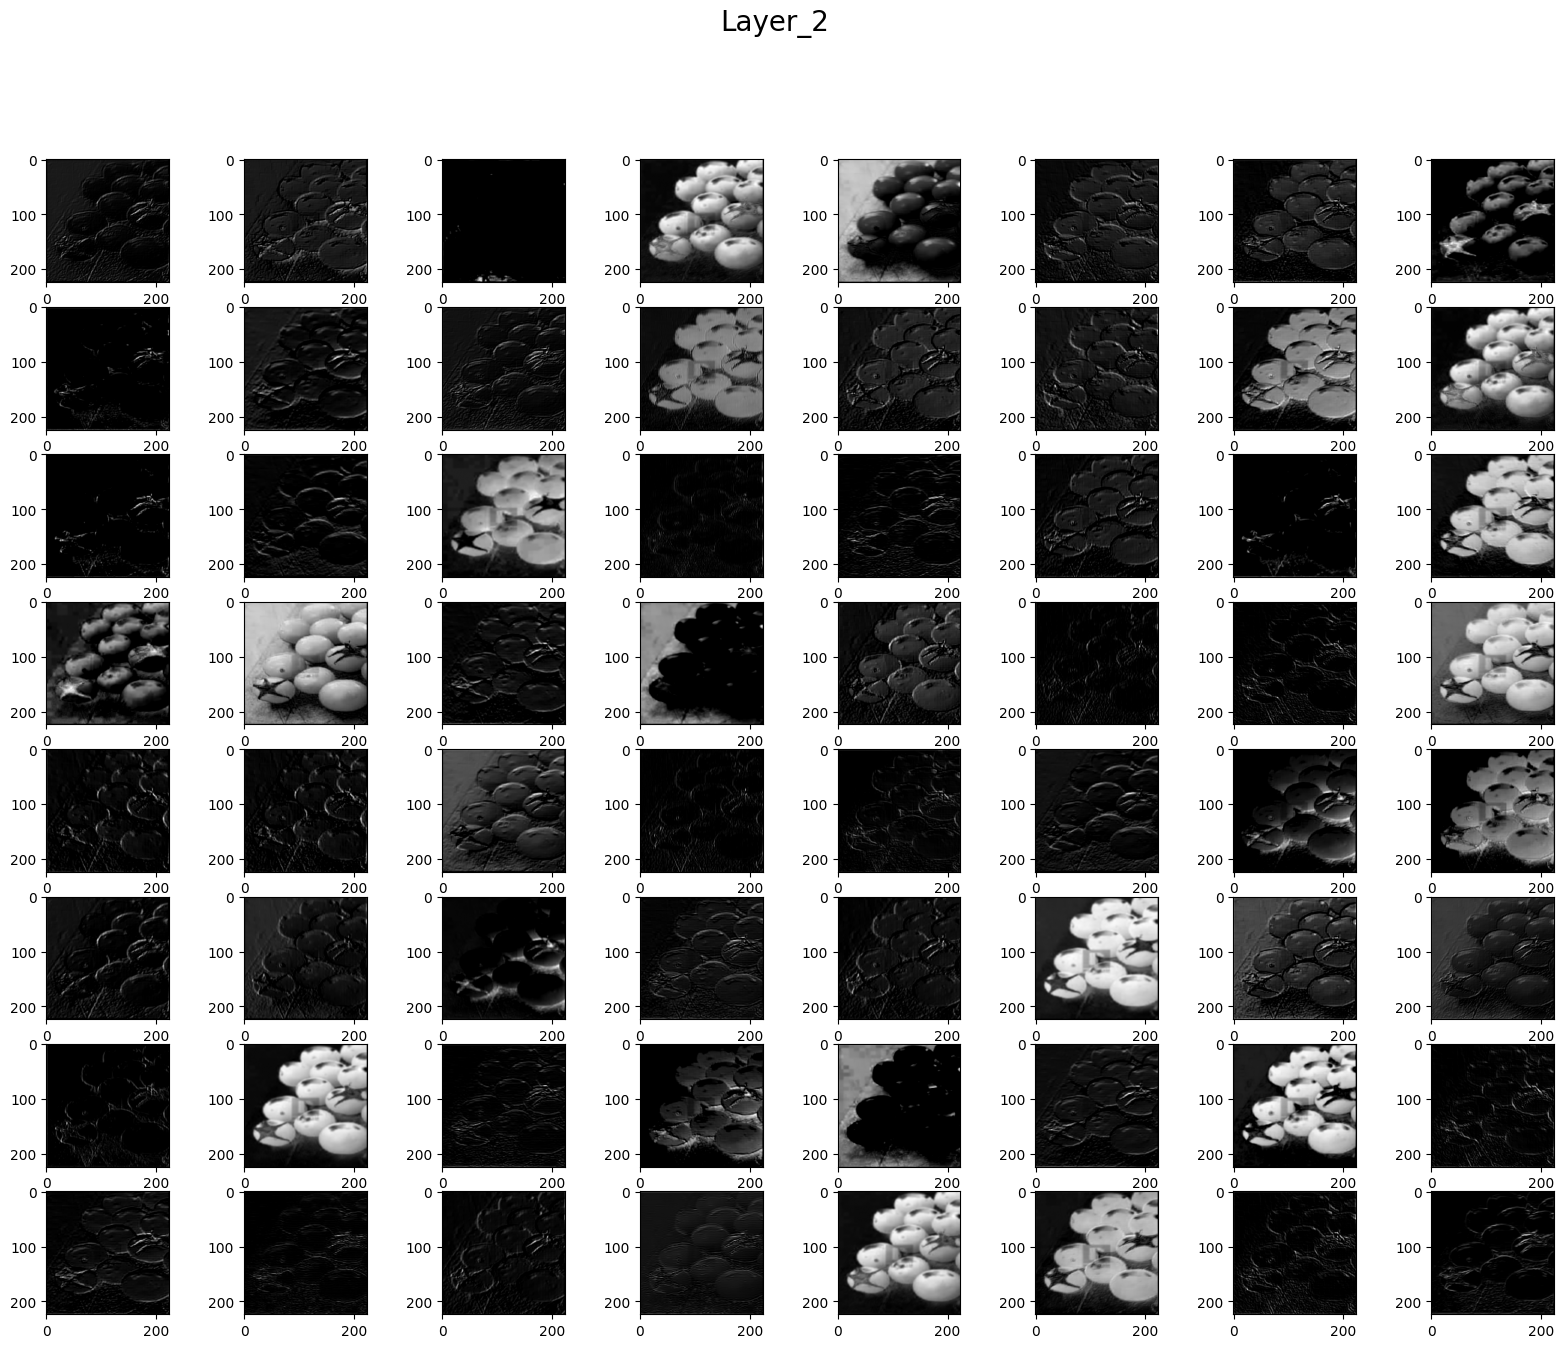

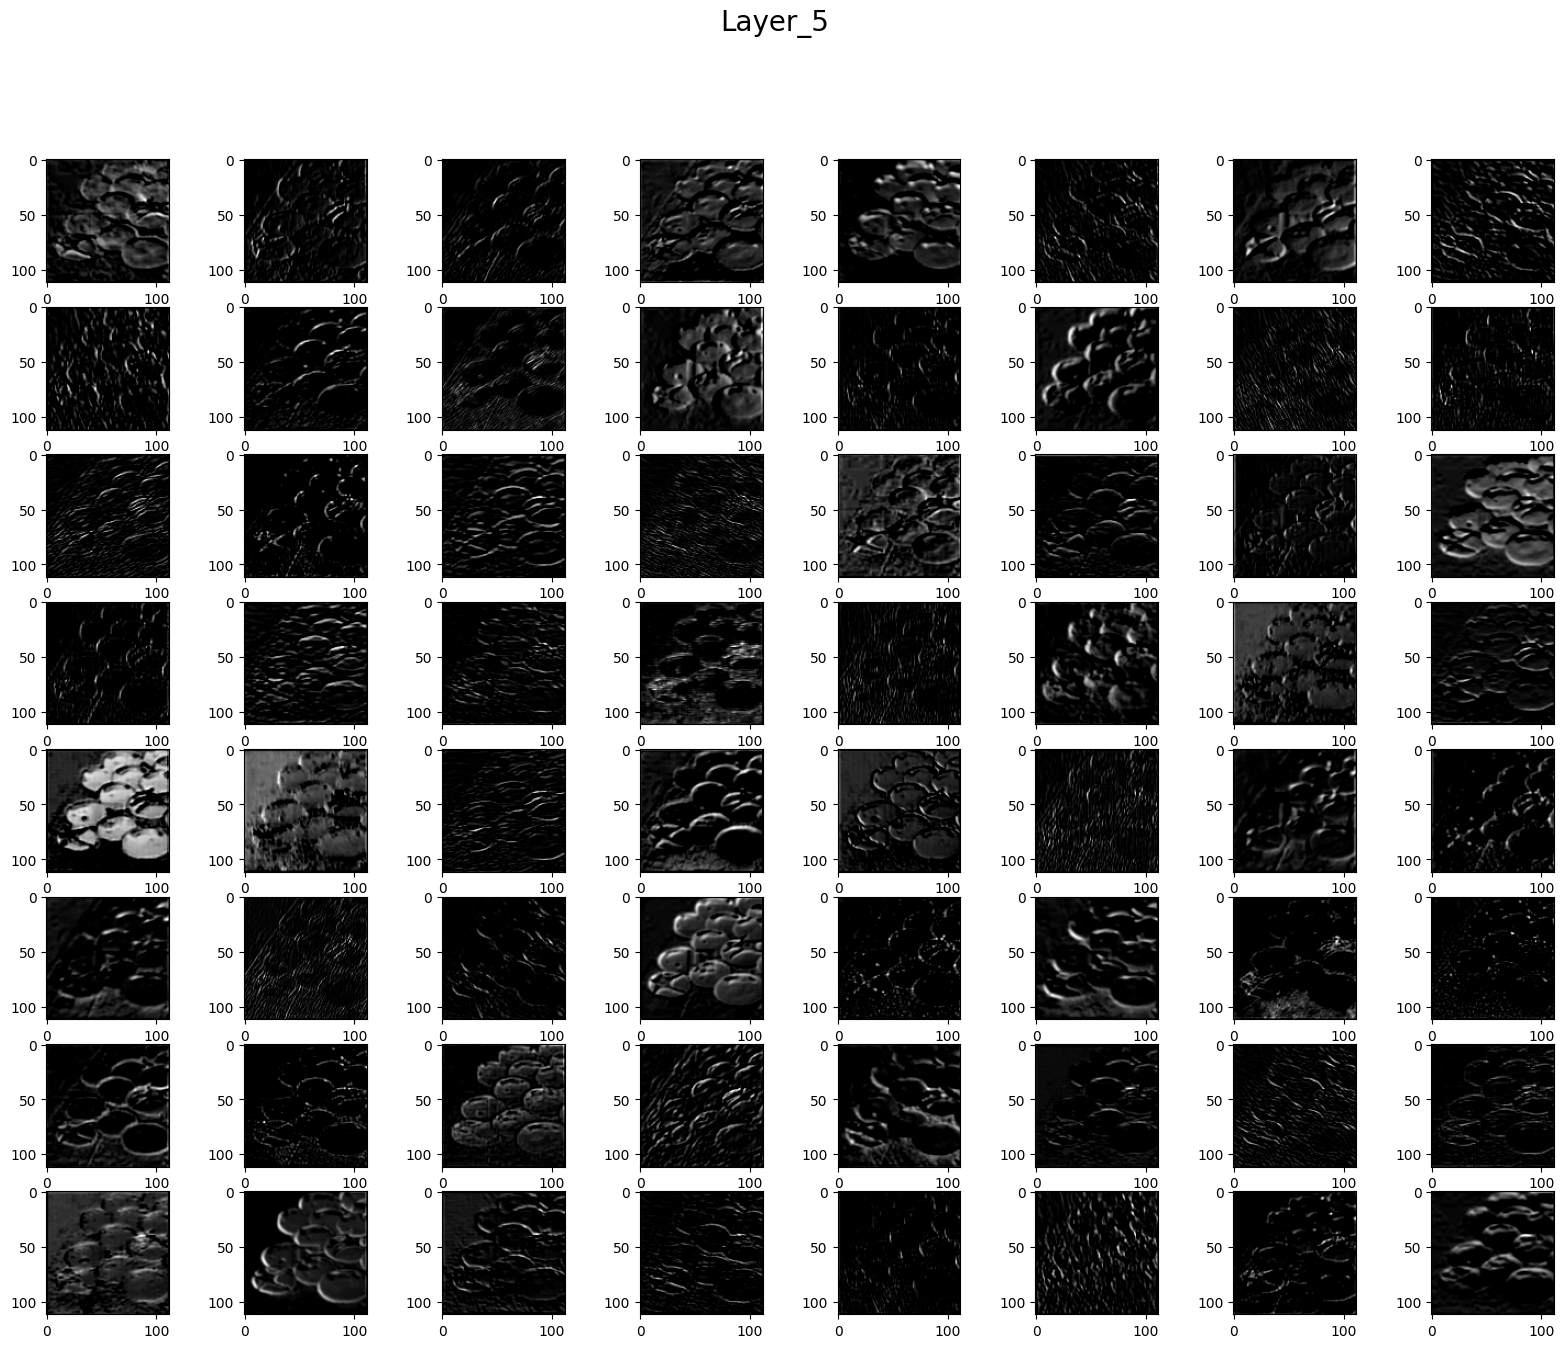

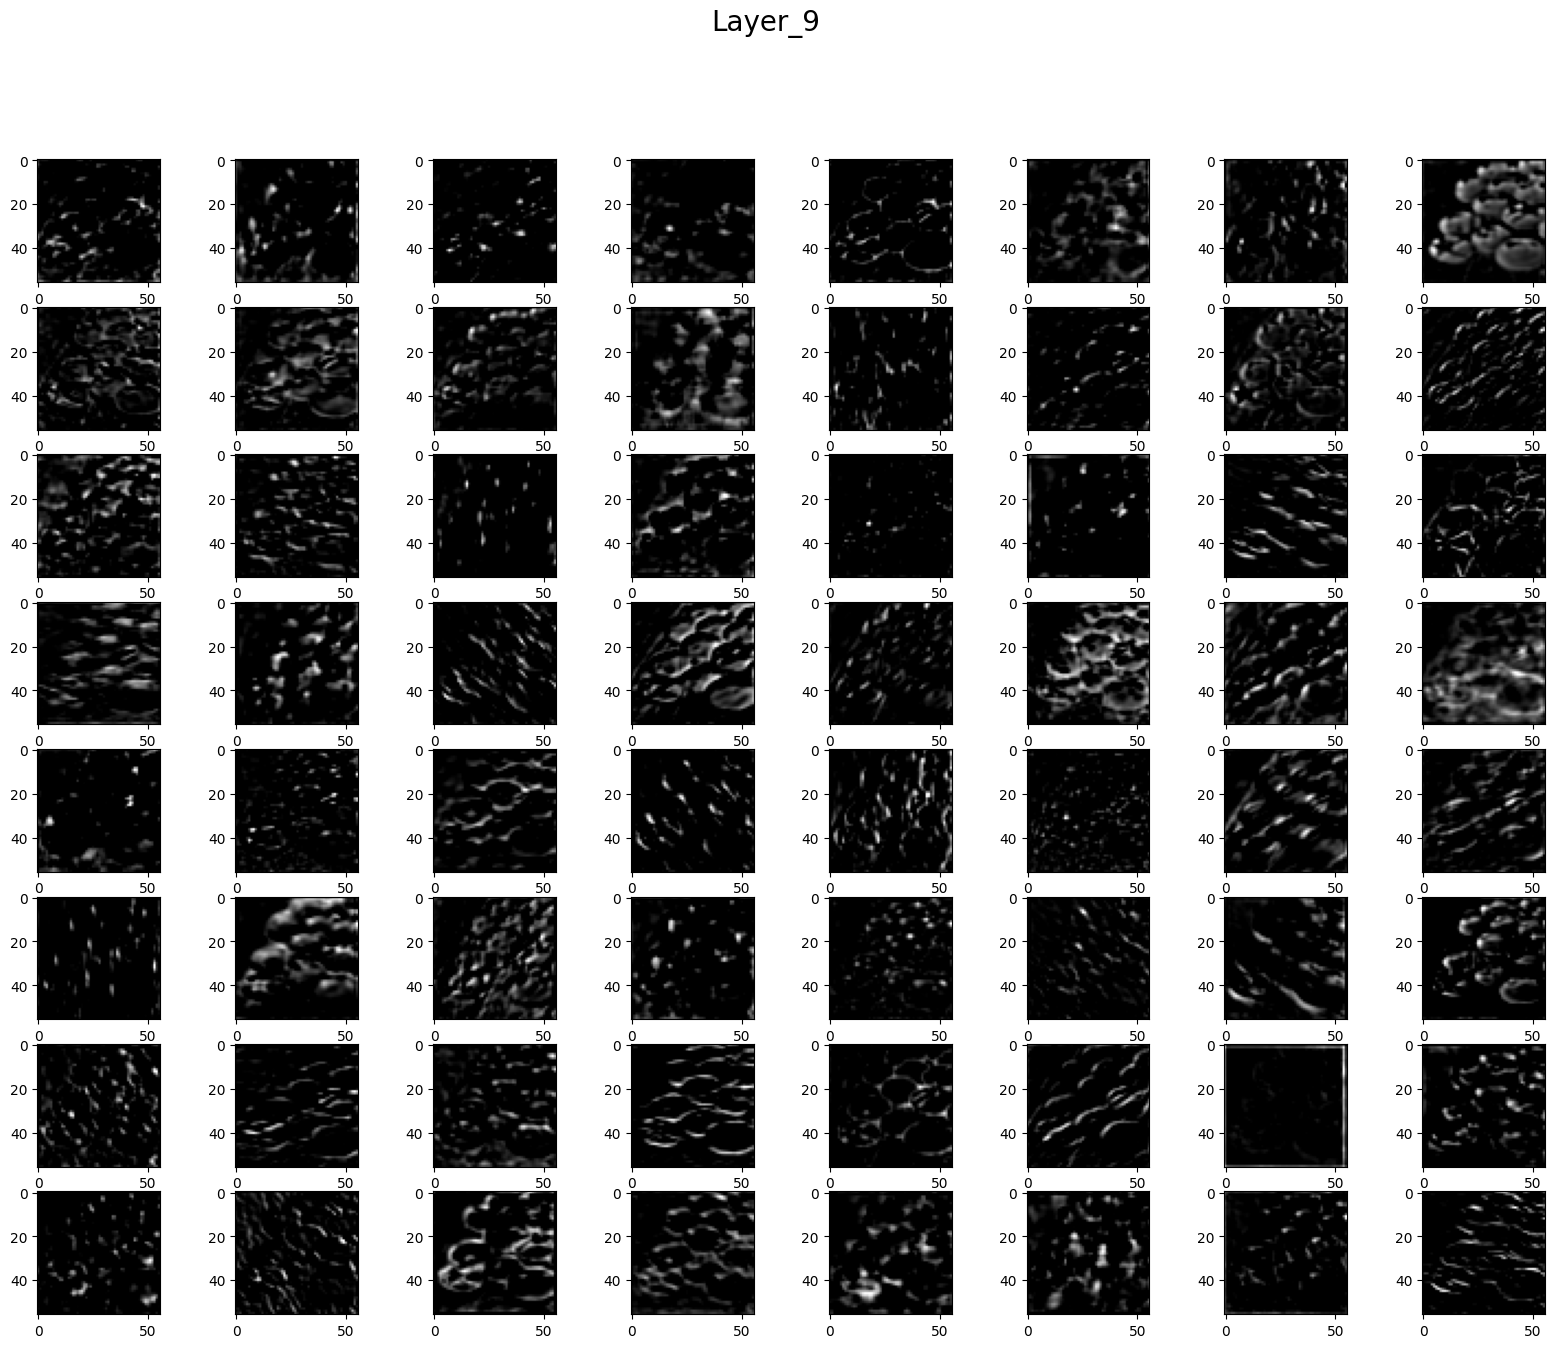

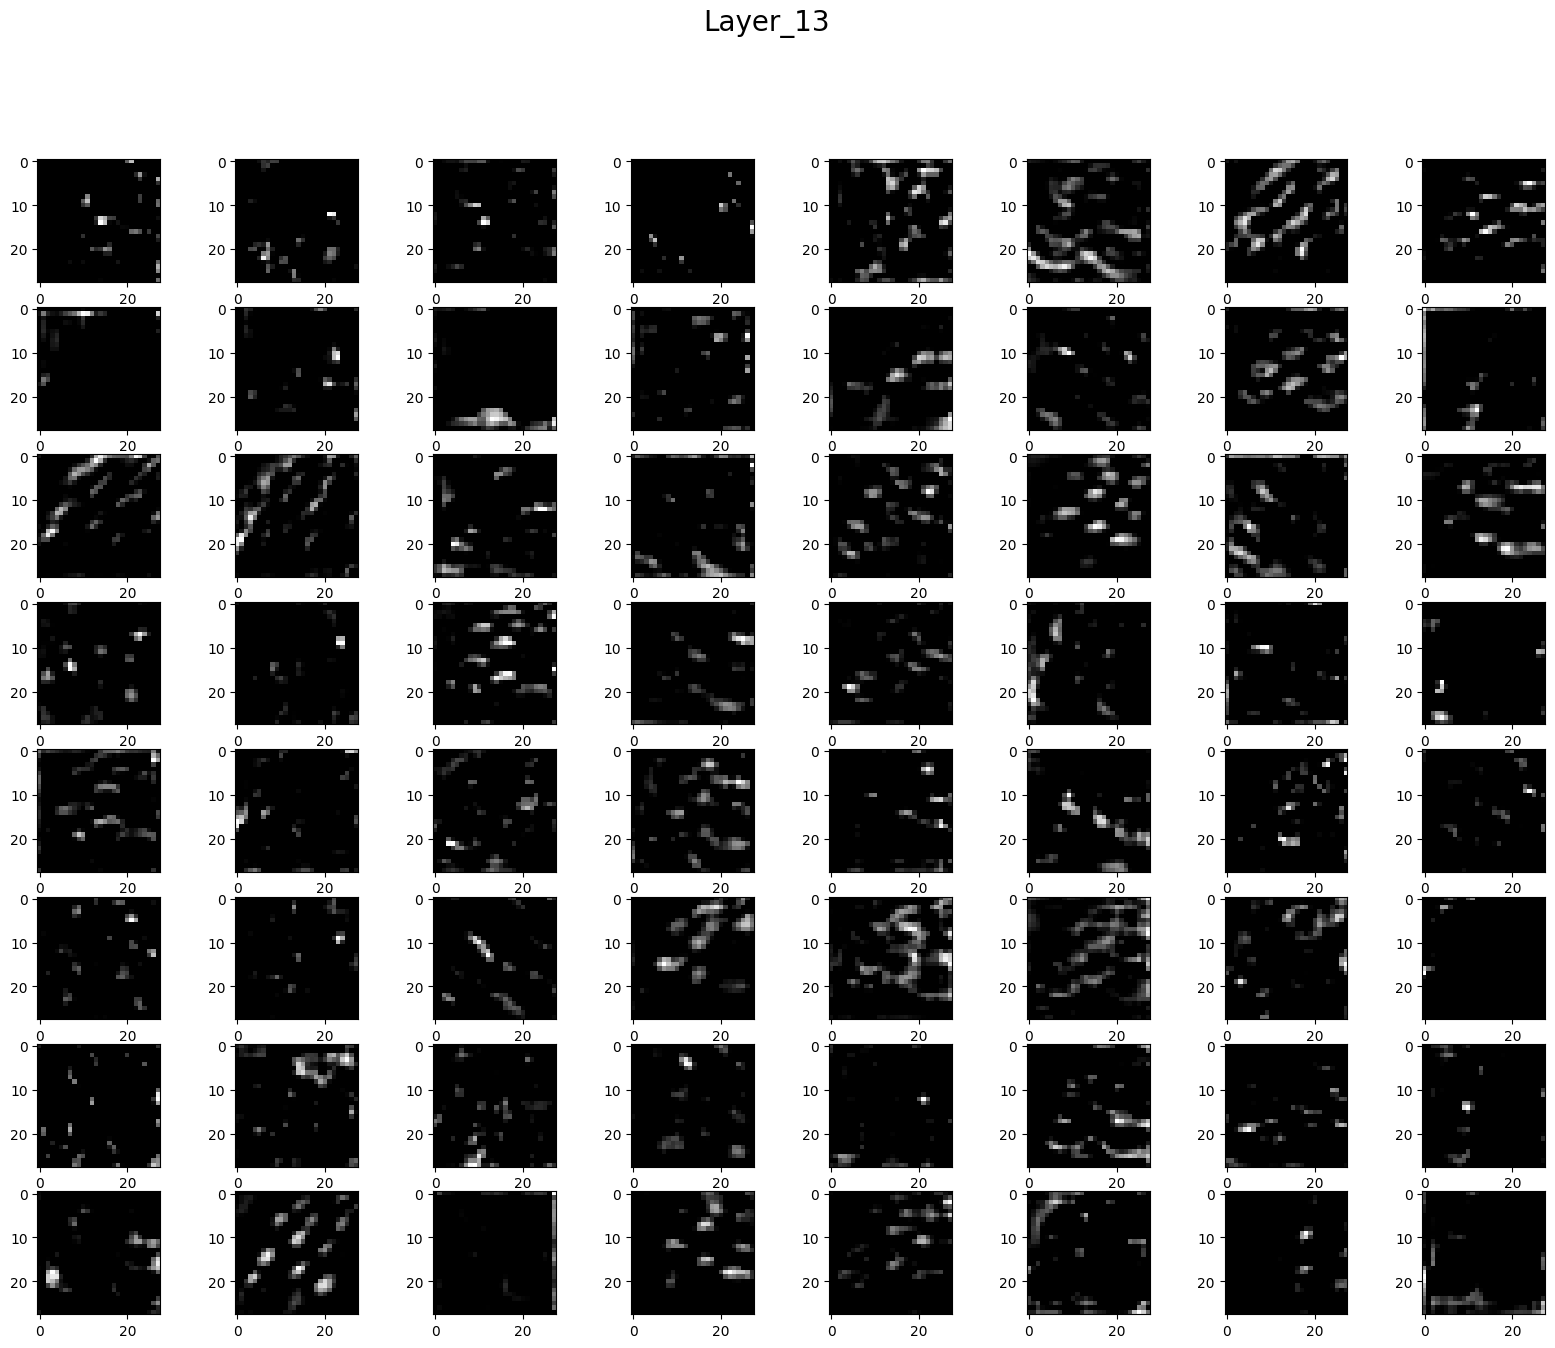

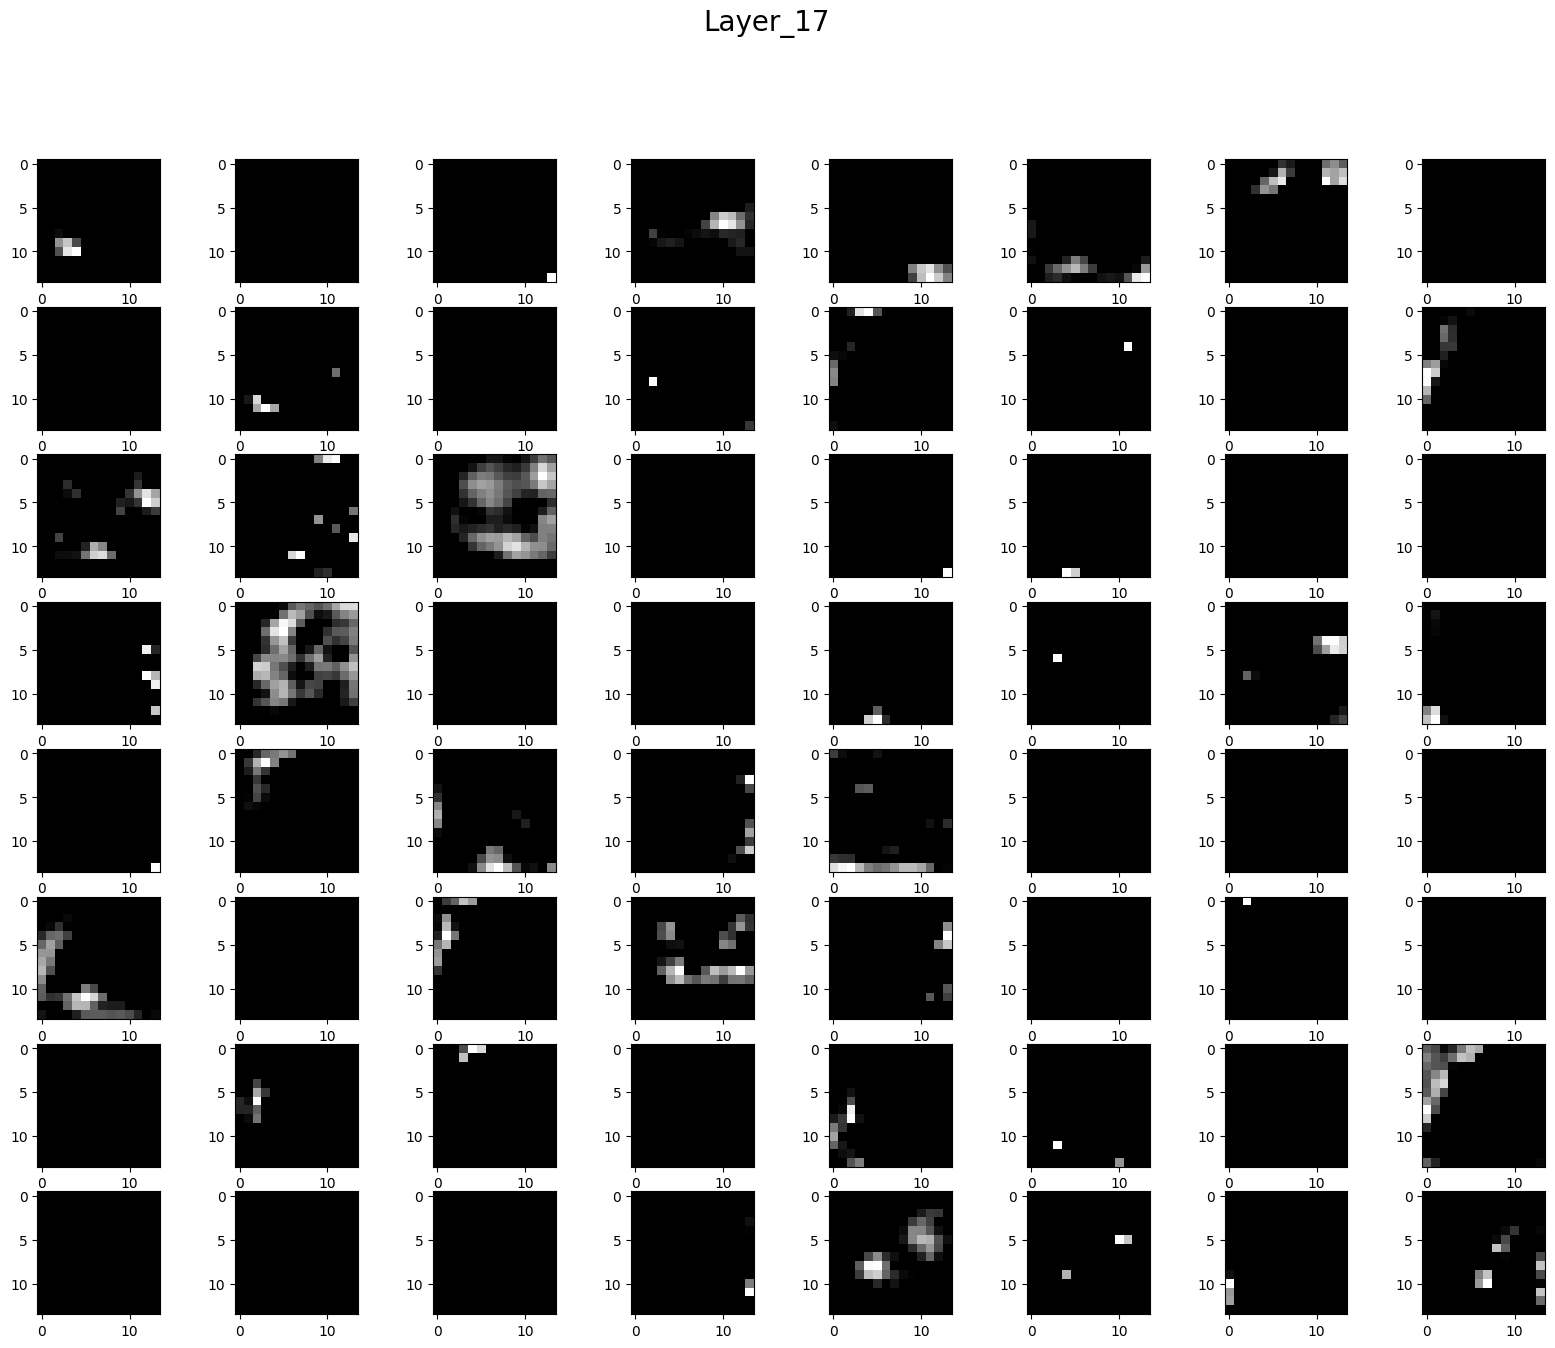

In [27]:
feature_map = model3.predict(image)

for i,fmap in zip(layer_index,feature_map):
    fig = pyplot.figure(figsize=(20,15))
    fig.suptitle("Layer_{}".format(i) , fontsize=20)
    for i in range(1,features.shape[3]+1):

        pyplot.subplot(8,8,i)
        pyplot.imshow(fmap[0,:,:,i-1] , cmap='gray')

pyplot.show()

In [28]:
print("The End")

The End
